In [1]:
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import glob
from pathlib import Path
from tqdm import tqdm
from io import BytesIO
from deepface import DeepFace
import cv2

2025-11-08 18:38:47.044013: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-08 18:38:47.639204: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-08 18:38:51.174653: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


25-11-08 18:38:52 - Directory /teamspace/studios/this_studio/.deepface has been created
25-11-08 18:38:52 - Directory /teamspace/studios/this_studio/.deepface/weights has been created


In [10]:
def get_race(race):
    if race == 0:
        return 'White'
    elif race == 2:
        return 'Black'
    elif race == 3:
        return 'Asian'
    elif race == 4:
        return 'Indian'
    else:
        return "Other"

The labels of each face image is embedded in the file name, formated like [age]_[gender]_[race]_[date&time].jpg

In [2]:
ages = []
genders = []
races = []
images_paths = []
for img_path in tqdm(glob.glob('./UTKFACE/*')):
    file_path = Path(img_path)
    file_name = file_path.stem
    split = file_name.split('_')
    ages.append(int(split[0]))
    genders.append(int(split[1]))
    races.append(int(split[2]))
    images_paths.append(img_path)

100%|██████████| 20856/20856 [00:00<00:00, 189758.53it/s]


In [3]:
results = []
for img_path in tqdm(glob.glob('./UTKFACE/*')):
    file_path = Path(img_path)
    file_name = file_path.stem
    split = file_name.split('_')
    age = int(split[0])
    gender = int(split[1])
    race = int(split[2])
    image_path = img_path
    
    dict_temp = {
        'image_path' : image_path,
        'age' : age,
        'gender' : gender,
        'race' : race,
    }
    results.append(dict_temp)

df = pd.DataFrame(results)

 84%|████████▎ | 17459/20856 [00:00<00:00, 167492.80it/s]

100%|██████████| 20856/20856 [00:00<00:00, 167469.60it/s]


In [15]:
df['race_decoded'] = df['race'].apply(lambda x: get_race(x))
df['gender_decoded'] = np.where(df['gender'] == 0, 'Male', "Female")

In [14]:
count_race = df['race_decoded'].value_counts().reset_index()
proportion_race = df['race_decoded'].value_counts(normalize = True).reset_index()
race = count_race.merge(proportion_race, on = ['race_decoded'], how = 'left')
race

,race_decoded,count,proportion
0,White,9315,0.446634
1,Other,4300,0.206176
2,Black,3513,0.168441
3,Asian,2054,0.098485
4,Indian,1674,0.080265


In [16]:
count_gender = df['gender_decoded'].value_counts().reset_index()
proportion_gender = df['gender_decoded'].value_counts(normalize = True).reset_index()
gender = count_gender.merge(proportion_gender, on = ['gender_decoded'], how = 'left')
gender

,gender_decoded,count,proportion
0,Female,10529,0.504843
1,Male,10327,0.495157


In [8]:
print(df['age'].max())
print(df['age'].min())

116
1


In [18]:
df = df[df['age'] <= 80]
df.to_parquet('./UTKFACE_dataset.parquet')

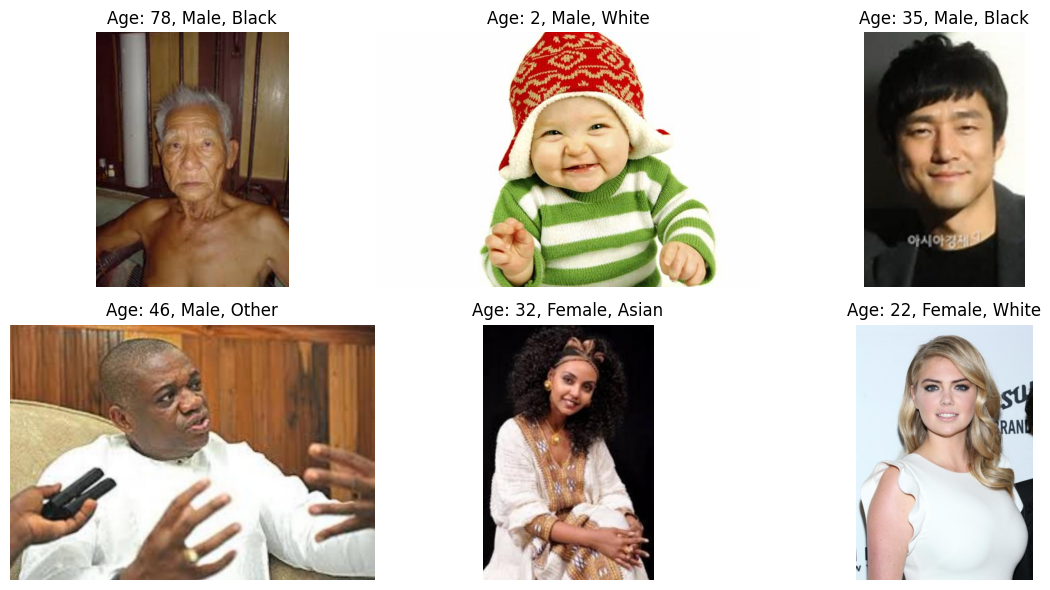

In [21]:
num_images = 6
cols = 3
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i in range(num_images):
    img = images[i]
    age = ages[i]
    gender = 'Male' if genders[i] == 0 else 'Female'
    race = get_race(races[i])

    r = i // cols
    c = i % cols
    
    axes[r, c].imshow(img)
    axes[r, c].set_title(f"Age: {age}, {gender}, {race}")
    axes[r, c].axis("off")

plt.tight_layout()
plt.show()